In [21]:
!export CUDA_VISIBLE_DEVICES=1

In [22]:
import torch
from src.models.our_method.swin_cafm import SwinCAFM


MODEL_FP = "/playpen/mufan/levi/tianlong-chen-lab/sparse-cafm/__exps__/bto/2025-04-15_16-52-36_bto/bto_best.pth"
model: SwinCAFM = torch.load(MODEL_FP).cuda()

/tmp/ipykernel_20212/481596049.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model: SwinCAFM = torch.load(MODEL_FP).cuda()


{'Mean roughness (Sa)': 1.3034298085301543,
 'RMS roughness (Sq)': 1.7170259658527698}


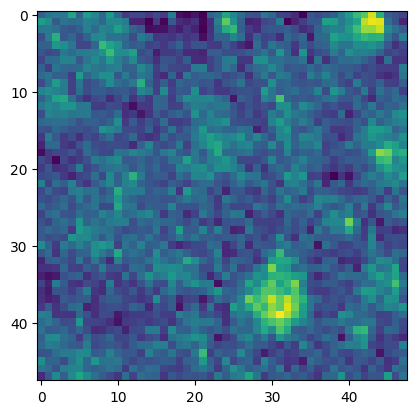

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from src.util.material_property_eval import calculate_roughness
from pprint import pprint

# load [64, 64] validation sample
data = np.load("/playpen/mufan/levi/tianlong-chen-lab/sparse-cafm/data/raw-data/3-12-25/A4 64_Z Height_Backward_012.npy")
data = torch.Tensor(data)[:48, :48]

plt.imshow(data);
pprint(calculate_roughness((data)))

{'Mean roughness (Sa)': 1.1550197465126644,
 'RMS roughness (Sq)': 1.5641883344130747}


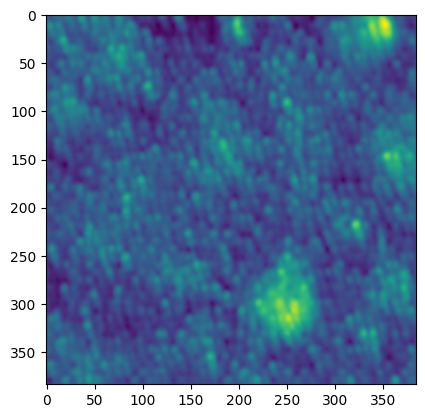

In [24]:
from src.datasets.mos2_sr import BTOSRDataset

dataset = BTOSRDataset()

# Normalize the input data
X = data
X = (X - dataset.topo_maps_min) / (dataset.topo_maps_max - dataset.topo_maps_min)

# Get model prediction
pred = model(X.cuda().unsqueeze(0))

# Undo normalization to map back to original distribution
pred_orig = pred * (dataset.topo_maps_max - dataset.topo_maps_min) + dataset.topo_maps_min
pred_orig_np = pred_orig.squeeze(0).detach().cpu().numpy()

# Visualize and compute roughness
plt.imshow(pred_orig_np)
pprint(calculate_roughness(pred_orig_np))


{'Mean roughness (Sa)': 1.4404056743081883,
 'RMS roughness (Sq)': 1.8474343693396504}


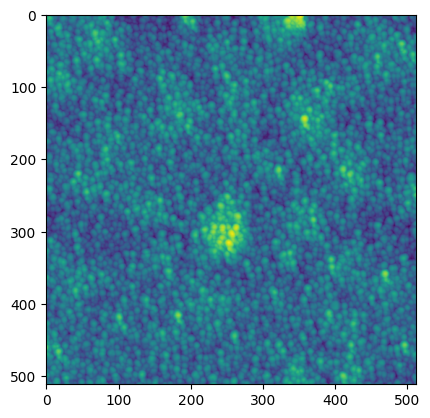

In [25]:
# show the original, ground-truth data
gt = np.load("data/raw-data/3-12-25/A4 512_Z Height_Backward_011.npy")
plt.imshow(gt);
pprint(calculate_roughness((gt)))